In [26]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
tf.random.set_seed(22)

In [4]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
dataset = pd.read_csv(url, names=column_names, na_values='?', comment='\t', sep=' ', skipinitialspace=True)
dataset = dataset.dropna()
dataset_tf = tf.convert_to_tensor(dataset, dtype=tf.float32)
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [14]:
dataset_shuffled = tf.random.shuffle(dataset_tf, seed=22)
train_data, test_data = dataset_shuffled[100:], dataset_shuffled[:100]
x_train, y_train = train_data[:, 1:], train_data[:, 0]
x_test, y_test = test_data[:, 1:], test_data[:, 0]

In [15]:
def onehot_origin(x):
    origin = tf.cast(x[:, -1], tf.int32)
    origin_oh = tf.one_hot(origin - 1, depth=3)
    x_ohe = tf.concat([x[:, :-1], origin_oh], axis=1)
    return x_ohe

x_train_ohe, x_test_ohe = onehot_origin(x_train), onehot_origin(x_test)
x_train_ohe.numpy()

array([[  4., 121., 115., ...,   0.,   1.,   0.],
       [  6., 198.,  95., ...,   1.,   0.,   0.],
       [  4., 112.,  88., ...,   1.,   0.,   0.],
       ...,
       [  8., 350., 125., ...,   1.,   0.,   0.],
       [  8., 350., 150., ...,   1.,   0.,   0.],
       [  4.,  79.,  67., ...,   0.,   1.,   0.]],
      shape=(292, 9), dtype=float32)

In [17]:
class Normalize(tf.Module):
    def __init__(self, x):
        super().__init__()
        self.mean = tf.math.reduce_mean(x, axis=0)
        self.std = tf.math.reduce_std(x, axis=0)

    def norm(self, x):
        return (x - self.mean) / self.std

    def unnorm(self, x):
        return x * self.std + self.mean


norm_x = Normalize(x_train_ohe)
norm_y = Normalize(y_train)
x_train_norm, y_train_norm = norm_x.norm(x_train_ohe), norm_y.norm(y_train)
x_test_norm, y_test_norm = norm_x.norm(x_test_ohe), norm_y.norm(y_test)

In [24]:
class LinearRegression(tf.Module):
    def __init__(self):
        super().__init__()
        self.built = False

    @tf.function
    def __call__(self, x):
        if not self.built:
            rand_w = tf.random.uniform(shape=[x.shape[-1], 1])
            rand_b = tf.random.uniform(shape=[])
            self.w = tf.Variable(rand_w)
            self.b = tf.Variable(rand_b)
            self.built = True
        y = tf.add(tf.matmul(x, self.w), self.b)
        return tf.squeeze(y, axis=1)

In [28]:
def mse_loss(y_pred, y):
    return tf.reduce_mean(tf.square(y_pred - y))

batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_norm, y_train_norm))
train_dataset = train_dataset.shuffle(buffer_size=x_train.shape[0]).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_norm, y_test_norm))
test_dataset = test_dataset.shuffle(buffer_size=x_test.shape[0]).batch(batch_size)

In [29]:
lin_reg = LinearRegression()
prediction = lin_reg(x_train_norm[:1])
prediction_unnorm = norm_y.unnorm(prediction)
prediction_unnorm.numpy()

array([24.795126], dtype=float32)

In [30]:
epochs = 100
learning_rate = 0.01
train_losses, test_losses = [], []
for epoch in range(epochs):
    batch_losses_train, batch_losses_test = [], []
    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            y_pred_batch = lin_reg(x_batch)
            batch_loss = mse_loss(y_pred_batch, y_batch)
        grads = tape.gradient(batch_loss, lin_reg.variables)
        for g, v in zip(grads, lin_reg.variables):
            v.assign_sub(learning_rate * g)
        batch_losses_train.append(batch_loss)
    for x_batch, y_batch in test_dataset:
        y_pred_batch = lin_reg(x_batch)
        batch_loss = mse_loss(y_pred_batch, y_batch)
        batch_losses_test.append(batch_loss)
    train_loss = tf.reduce_mean(batch_losses_train)
    test_loss = tf.reduce_mean(batch_losses_test)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    if epoch % 10 == 0:
        print(f'Mean squared error for step {epoch}: {train_loss.numpy():.3f}')


print(f'\nFinal train loss: {train_loss:.3f}')
print(f'\nFinal test loss: {test_loss:.3f}')

Mean squared error for step 0: 2.853
Mean squared error for step 10: 0.481
Mean squared error for step 20: 0.293
Mean squared error for step 30: 0.234
Mean squared error for step 40: 0.206
Mean squared error for step 50: 0.196
Mean squared error for step 60: 0.193
Mean squared error for step 70: 0.188
Mean squared error for step 80: 0.190
Mean squared error for step 90: 0.186

Final train loss: 0.181

Final test loss: 0.189


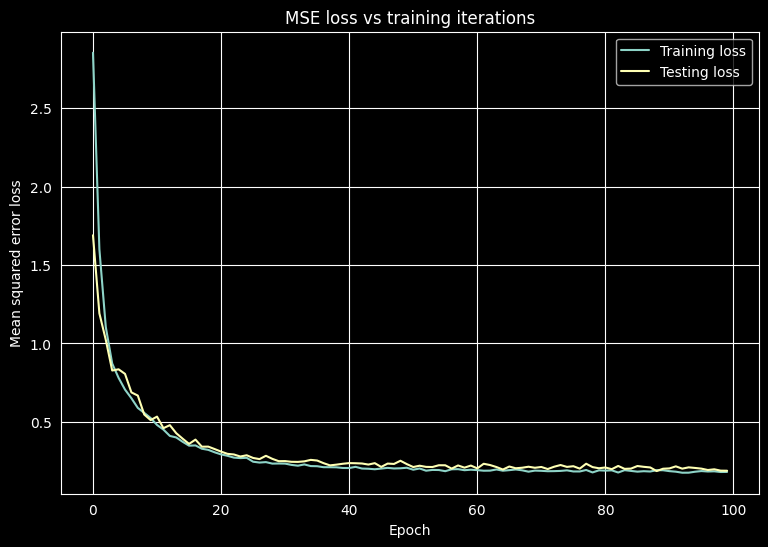

In [31]:
matplotlib.rcParams['figure.figsize'] = [9, 6]

plt.plot(range(epochs), train_losses, label = "Training loss")
plt.plot(range(epochs), test_losses, label = "Testing loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error loss")
plt.legend()
plt.title("MSE loss vs training iterations");